# Fashion-MNIST: CNN + baseline + inference

**Author:** Tegar Reski Pratama (Informatika, Universitas Muhammadiyah Malang). This notebook analyzes the trained model from `python -m fashion_ai.train`. Run the cells sequentially after training. Test data is used for final reporting, never for training or early stopping.


## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from fashion_ai import LABELS
from fashion_ai.data import load_splits
from fashion_ai.inference import load_model, predict_bytes

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS = ROOT / 'artifacts'
print('Artifact directory:', ARTIFACTS)


Artifact directory: /workspace/scratch/7ed7c6aed3f5/fashion-mnist-cnn-api/artifacts


## 2. Load the dataset and check label distribution

In [2]:
(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_splits(seed=42)
print('Train:', x_train.shape, 'Validation:', x_val.shape, 'Test:', x_test.shape)
print('Train class counts:', np.bincount(y_train).tolist())
print('Validation class counts:', np.bincount(y_val).tolist())
print('Test class counts:', np.bincount(y_test).tolist())
assert x_train.min() >= 0 and x_train.max() <= 1
assert x_test.shape == (10000, 28, 28, 1)


Train: (54000, 28, 28, 1) Validation: (6000, 28, 28, 1) Test: (10000, 28, 28, 1)
Train class counts: [5400, 5400, 5400, 5400, 5400, 5400, 5400, 5400, 5400, 5400]
Validation class counts: [600, 600, 600, 600, 600, 600, 600, 600, 600, 600]
Test class counts: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


## 3. Inspect sample images

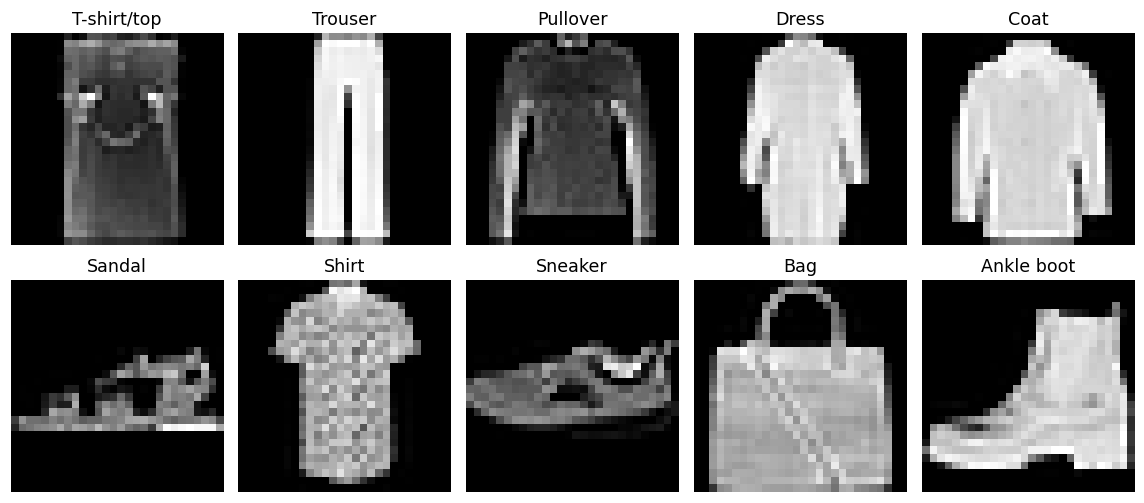

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for label, ax in enumerate(axes.flat):
    index = int(np.flatnonzero(y_train == label)[0])
    ax.imshow(x_train[index, :, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.set_title(LABELS[label]); ax.axis('off')
plt.tight_layout(); plt.show()


## 4. Read the genuine training record

In [4]:
metrics = json.loads((ARTIFACTS / 'metrics.json').read_text())
print('Run type:', metrics['run_type'], 'Epochs:', metrics['epochs_run'])
for key in ['baseline_validation_accuracy', 'baseline_test_accuracy', 'cnn_test_accuracy', 'cnn_test_macro_f1']:
    print(f'{key}: {metrics[key]:.4f}')
assert metrics['run_type'] == 'full'


Run type: full Epochs: 8
baseline_validation_accuracy: 0.8508
baseline_test_accuracy: 0.8294
cnn_test_accuracy: 0.9089
cnn_test_macro_f1: 0.9079


## 5. Compare learning curves

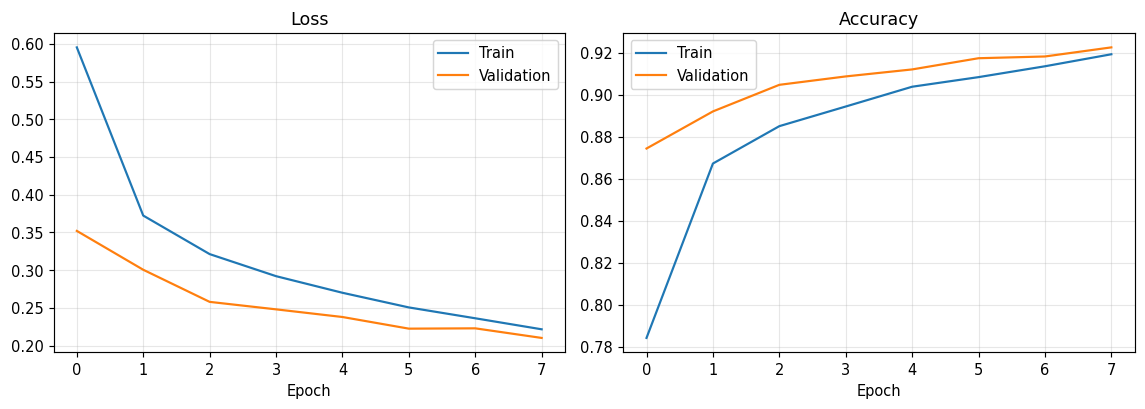

In [5]:
history = metrics['history']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ['loss', 'accuracy']):
    ax.plot(history[metric], label='Train')
    ax.plot(history['val_' + metric], label='Validation')
    ax.set(xlabel='Epoch', title=metric.capitalize()); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


## 6. Load saved model and evaluate held-out test data

In [6]:
model = load_model(ARTIFACTS / 'model.keras')
logits = np.asarray(model.predict(x_test, batch_size=256, verbose=0))
pred = logits.argmax(axis=1)
print(classification_report(y_test, pred, target_names=LABELS, digits=4))
print('Accuracy from model:', round(float(np.mean(pred == y_test)), 4))
assert abs(float(np.mean(pred == y_test)) - metrics['cnn_test_accuracy']) < 1e-8


              precision    recall  f1-score   support

 T-shirt/top     0.8440    0.8710    0.8573      1000
     Trouser     0.9929    0.9810    0.9869      1000
    Pullover     0.8721    0.8390    0.8552      1000
       Dress     0.8913    0.9350    0.9126      1000
        Coat     0.8080    0.8880    0.8461      1000
      Sandal     0.9850    0.9860    0.9855      1000
       Shirt     0.7837    0.6740    0.7247      1000
     Sneaker     0.9500    0.9700    0.9599      1000
         Bag     0.9821    0.9870    0.9845      1000
  Ankle boot     0.9746    0.9580    0.9662      1000

    accuracy                         0.9089     10000
   macro avg     0.9084    0.9089    0.9079     10000
weighted avg     0.9084    0.9089    0.9079     10000

Accuracy from model: 0.9089


## 7. Which classes get confused?

Shirt -> T-shirt/top: 131
Shirt -> Coat: 92
Pullover -> Coat: 81
T-shirt/top -> Shirt: 77
Shirt -> Pullover: 54


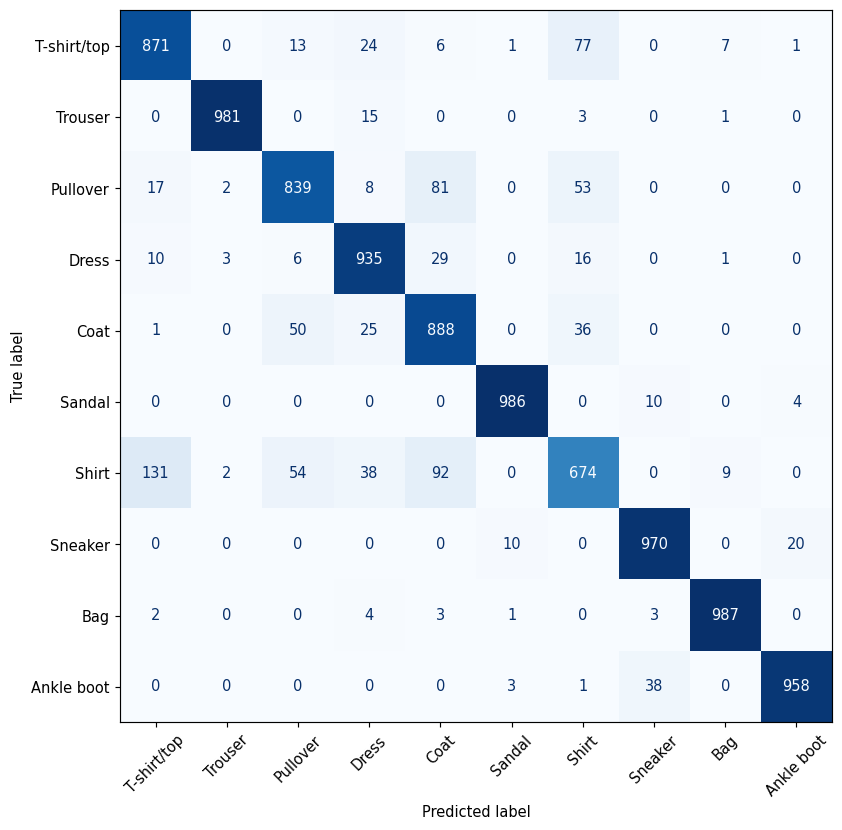

In [7]:
matrix = confusion_matrix(y_test, pred, labels=range(10))
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(matrix, display_labels=LABELS).plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.tight_layout(); plt.show()
tmp = matrix.copy(); np.fill_diagonal(tmp, 0)
flat = np.argsort(tmp.ravel())[-5:][::-1]
for pos in flat:
    actual, predicted = np.unravel_index(pos, tmp.shape)
    print(f'{LABELS[actual]} -> {LABELS[predicted]}: {tmp[actual, predicted]}')


## 8. Inspect difficult mistakes

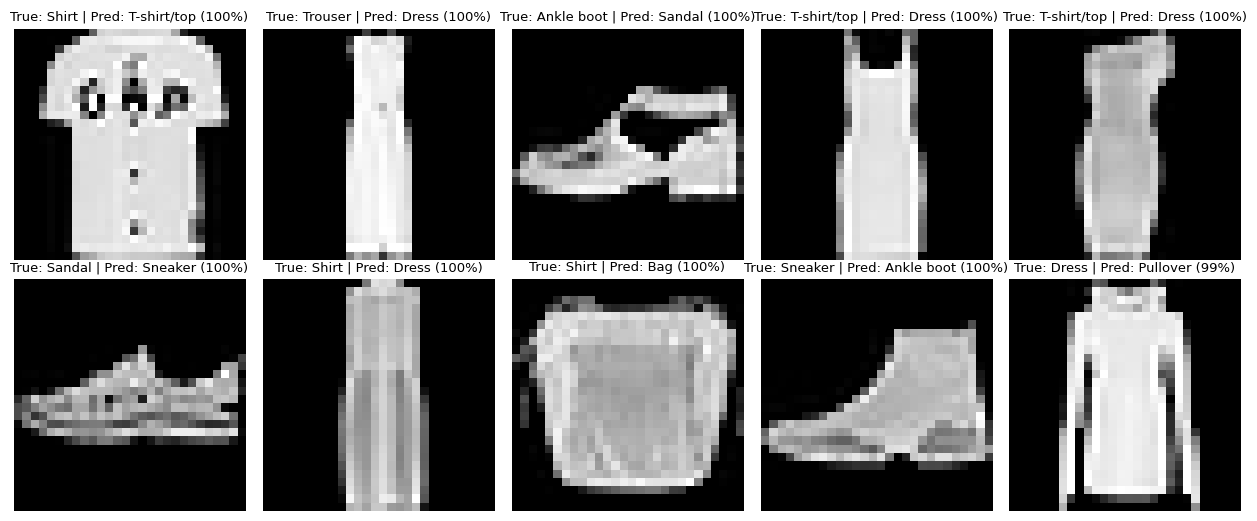

In [8]:
prob = np.exp(logits - logits.max(axis=1, keepdims=True))
prob /= prob.sum(axis=1, keepdims=True)
wrong = np.flatnonzero(pred != y_test)
most_confident = wrong[np.argsort(prob[wrong, pred[wrong]])[-10:][::-1]]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in zip(most_confident, axes.flat):
    ax.imshow(x_test[i, :, :, 0], cmap='gray')
    ax.set_title(f'True: {LABELS[y_test[i]]} | Pred: {LABELS[pred[i]]} ({prob[i, pred[i]]:.0%})', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 9. Verify the saved model through the same PNG inference path used by the API

In [9]:
from io import BytesIO
from PIL import Image
buffer = BytesIO()
Image.fromarray((x_test[0, :, :, 0] * 255).astype('uint8')).save(buffer, format='PNG')
result = predict_bytes(model, buffer.getvalue())
print('True class:', LABELS[y_test[0]])
print('Top-3:', result)
assert result[0]['class_id'] == int(pred[0])


True class: Ankle boot
Top-3: [{'class_id': 9, 'label': 'Ankle boot', 'probability': 0.9988328814506531}, {'class_id': 7, 'label': 'Sneaker', 'probability': 0.001050173887051642}, {'class_id': 5, 'label': 'Sandal', 'probability': 0.00011441303649917245}]


## Interpretation

Fashion-MNIST is a 28×28 grayscale benchmark, so the API expects similarly prepared images. Compare test accuracy and macro F1 with the linear baseline; inspect the confusion matrix and confident mistakes before claiming strengths. The model is a demonstration, not a production-ready fashion product recognizer. See `README.md` for setup, data citation, limits, and API usage.
